# H1 클러스터링 (6mo 전환): 최근 6개월 + 4-시스템 다축

**H1 가설:** 최근 6개월간 주요 성장 지표가 낮은 활성 캐릭터들은 일반 성장 캐릭터들과 구분되는 성장 정체 군집으로 식별될 것이다.

**목표:** K-Means로 성장 정체(주차 후보) 군집을 식별하고, DBSCAN으로 같은 피처 공간의 보조 구조를 검증한다.

**입력:** `data/features_monthly.csv`(비-delta 컬럼) + `data/monthly_snapshots_raw.csv`(최근 6개월 2025-12~2026-05 avg_monthly_delta_* 재산출 override) + `data/main_characters.csv`(class_group) 2,000명.

**채택 피처셋(`optimal_feature_set.json`):** 4-시스템 다축 `[cp_slog, hexa_avg, union_log, auth_log]` — 전투력·헥사·유니온·심볼 미재투자. 운영점 k = elbow(광의).

**전처리(`feature_selection.ipynb`와 동일):**
- `slog_delta_cp`: 전투력 delta p01~p99 winsorize 후 signed-log(음수=감소 보존)
- `delta_hexa`(hexa_avg): lower 0 + upper p99 clip
- `log_delta_union`/`log_delta_auth`: lower 0 + upper p99 clip 후 log1p


In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=_font_path).get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
UPPER_CLIP_Q = 0.99
CP_WINSOR_Q = (0.01, 0.99)

# ── 6개월 윈도우 (feature_selection.ipynb 동일) ──────────────────────────────
# 주차=현재 행동 → 최근 6개월 delta 로 군집화(12mo 대비 recall 0.57→0.83).
# 6개월 delta = features_monthly.csv 의 recent6_delta_* 컬럼(collect_features.py 산출).
#   raw 스냅샷 6mo 재산출과 corr=1.0·diff=0 동등 → features_monthly 단독 재현. 12mo delta override.
WINDOW = ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05"]
RECENT6_MAP = {
    "avg_monthly_delta_combat_power":     "recent6_delta_combat_power",
    "avg_monthly_delta_union_level":      "recent6_delta_union_level",
    "avg_monthly_delta_authentic_symbol": "recent6_delta_authentic_symbol",
    "avg_monthly_delta_hexa":             "recent6_delta_hexa",
    "avg_monthly_delta_level":            "recent6_delta_level",
}

def qclip_nonnegative(s, upper_q=UPPER_CLIP_Q):
    s = pd.to_numeric(s, errors="coerce").clip(lower=0)
    upper = s.quantile(upper_q)
    return s.clip(upper=upper)

def winsor_quantile(s, lower_q=CP_WINSOR_Q[0], upper_q=CP_WINSOR_Q[1]):
    s = pd.to_numeric(s, errors="coerce")
    lower, upper = s.quantile([lower_q, upper_q])
    return s.clip(lower=lower, upper=upper)

def find_elbow_k(ks, inertias):
    x = np.array(ks, dtype=float); y = np.array(inertias, dtype=float)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0) + 1e-12
    return ks[int(np.argmax(num / den))]

# 데이터 로드 + 6mo override ──────────────────────────────────────────────────
df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig",
                 usecols=["ocid", "class_group"])
df = df_raw.merge(mc, on="ocid", how="inner")

# 6mo override: 12mo avg_monthly_delta_* 를 recent6_delta_*(최근 6개월) 로 교체
for tgt, src in RECENT6_MAP.items():
    df[tgt] = df[src]

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290],
                         labels=["270-279", "280-285", "286-290"])

_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power",
         "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = winsor_quantile(df["avg_monthly_delta_combat_power"])
df["delta_union"] = qclip_nonnegative(df["avg_monthly_delta_union_level"])
df["delta_auth"] = qclip_nonnegative(df["avg_monthly_delta_authentic_symbol"])
df["delta_level"] = qclip_nonnegative(df["avg_monthly_delta_level"])
df["delta_hexa"] = qclip_nonnegative(df["avg_monthly_delta_hexa"])
# 재투자 축 heavy-tail → log1p (채택 클러스터링 축; feature_selection.ipynb 동일)
df["log_delta_union"] = np.log1p(df["delta_union"])
df["log_delta_auth"] = np.log1p(df["delta_auth"])
df["log_delta_hexa"] = np.log1p(df["delta_hexa"])
# 전투력 음수(감소=주차) 보존 signed-log (채택 클러스터링 축)
df["slog_delta_cp"] = np.sign(df["delta_cp_winsor"]) * np.log1p(np.abs(df["delta_cp_winsor"]))
df_final = df.reset_index(drop=True)

_stag = ["delta_level", "delta_cp_winsor", "delta_union", "delta_auth"]
df_final["stagnation_score"] = (
    sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int) for c in _stag)
)

# 채택 피처셋 매핑 (feature_selection.ipynb / optimal_feature_set.json) ─────────
FEATURE_MAP = {
    "union_avg": "delta_union",
    "cp_avg": "delta_cp_winsor",
    "level_avg": "delta_level",
    "auth_avg": "delta_auth",
    "hexa_avg": "delta_hexa",
    "union_log": "log_delta_union",
    "auth_log": "log_delta_auth",
    "cp_slog": "slog_delta_cp",
    "hexa_log": "log_delta_hexa",
}
opt = {}
if os.path.exists("optimal_feature_set.json"):
    opt = json.load(open("optimal_feature_set.json", encoding="utf-8"))
selected = opt.get("features", ["cp_slog", "hexa_avg", "union_log", "auth_log"])
CLUSTER_FEATURES = [FEATURE_MAP.get(f, f) for f in selected]
FINAL_K = int(opt.get("k", 4))

X_raw  = df_final[CLUSTER_FEATURES].dropna()
idx    = X_raw.index
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

# 외부 검증용 proxy 라벨 (성장 정체) ──────────────────────────────────────────
park         = (df_final["stagnation_score"] >= 4)
stag4        = (df_final["stagnation_score"] == 4)
parked_proxy = (df_final["delta_level"] <= 0.1)

BAND_LABELS  = ["270-279", "280-285", "286-290"]
BAND_PALETTE = {"270-279": "#4e79a7", "280-285": "#f28e2b", "286-290": "#e15759"}

print(f"df_final           : {len(df_final):,}명  |  6mo delta = recent6_delta_* ({WINDOW[0]}~{WINDOW[-1]})")
print(f"채택 피처(alias)   : {selected}")
print(f"클러스터링 컬럼    : {CLUSTER_FEATURES}")
print(f"클러스터링 대상    : {len(X):,}명  (FINAL_K={FINAL_K})")
print(f"park(stag>=4)      : {park.mean():.1%} (n={int(park.sum())})  |  "
      f"parked_proxy(Δlv<=0.1): {parked_proxy.mean():.1%}")
print(f"clip policy        : nonnegative deltas upper p{int(UPPER_CLIP_Q*100)}, combat_power p01-p99")

df_final           : 2,000명  |  6mo delta = recent6_delta_* (2025-12~2026-05)
채택 피처(alias)   : ['cp_slog', 'hexa_avg', 'union_log', 'auth_log']
클러스터링 컬럼    : ['slog_delta_cp', 'delta_hexa', 'log_delta_union', 'log_delta_auth']
클러스터링 대상    : 2,000명  (FINAL_K=4)
park(stag>=4)      : 7.3% (n=147)  |  parked_proxy(Δlv<=0.1): 14.2%
clip policy        : nonnegative deltas upper p99, combat_power p01-p99


## 피처 진단: 단독 silhouette + leave-one-out

채택셋 4피처 각각의 **단독 클러스터 분리력**과 **leave-one-out 기여도**(제거 시 silhouette 변화)를 확인.
`Δ<0` = 제거 시 악화 = 유지해야 할 피처.

── 단독 피처 silhouette ──


,feature,best_k,silhouette
0,slog_delta_cp,2,0.9547
1,log_delta_union,2,0.7548
2,log_delta_auth,8,0.7467
3,delta_hexa,2,0.6425



전체 3피처 best silhouette = 0.3835 (k=6)
── leave-one-out (Δ<0 = 유지해야 할 피처) ──


,dropped,silhouette_wo,delta_vs_full
0,slog_delta_cp,0.3890,0.0055
1,log_delta_union,0.4695,0.0861
2,delta_hexa,0.4916,0.1081
3,log_delta_auth,0.5257,0.1423


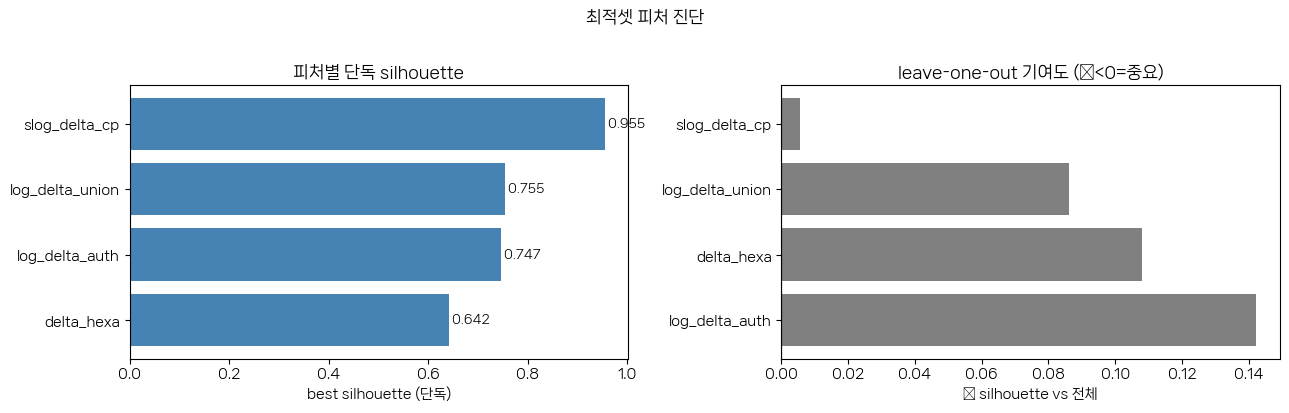

In [2]:
ks_fs = list(range(2, 9))

def best_silhouette(mat):
    sils = [silhouette_score(mat,
                KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(mat))
            for k in ks_fs]
    return max(sils), ks_fs[int(np.argmax(sils))]

# (1) 단독 피처 silhouette
rows = []
for feat in CLUSTER_FEATURES:
    Xf = StandardScaler().fit_transform(df_final.loc[idx, feat].values.reshape(-1, 1))
    sil, bk = best_silhouette(Xf)
    rows.append({"feature": feat, "best_k": bk, "silhouette": sil})
feat_sil = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("── 단독 피처 silhouette ──"); display(feat_sil.round(4))

# (2) leave-one-out
base_sil, base_k = best_silhouette(X)
loo = []
for feat in CLUSTER_FEATURES:
    keep = [c for c in CLUSTER_FEATURES if c != feat]
    Xk = StandardScaler().fit_transform(df_final.loc[idx, keep].values)
    s, _ = best_silhouette(Xk)
    loo.append({"dropped": feat, "silhouette_wo": s, "delta_vs_full": s - base_sil})
loo_df = pd.DataFrame(loo).sort_values("delta_vs_full").reset_index(drop=True)
print(f"\n전체 3피처 best silhouette = {base_sil:.4f} (k={base_k})")
print("── leave-one-out (Δ<0 = 유지해야 할 피처) ──"); display(loo_df.round(4))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
fs_r = feat_sil.iloc[::-1]
axL.barh(fs_r["feature"], fs_r["silhouette"], color="steelblue")
axL.set_xlabel("best silhouette (단독)"); axL.set_title("피처별 단독 silhouette")
for i, v in enumerate(fs_r["silhouette"]): axL.text(v, i, f" {v:.3f}", va="center", fontsize=9)
loo_r = loo_df.iloc[::-1]
colors = ["crimson" if d < 0 else "gray" for d in loo_r["delta_vs_full"]]
axR.barh(loo_r["dropped"], loo_r["delta_vs_full"], color=colors)
axR.axvline(0, color="black", linewidth=0.8)
axR.set_xlabel("Δ silhouette vs 전체"); axR.set_title("leave-one-out 기여도 (Δ<0=중요)")
plt.suptitle("최적셋 피처 진단", y=1.02); plt.tight_layout()
plt.savefig("figures/00_feature_silhouette.png", dpi=150, bbox_inches="tight"); plt.show()


## K-Means: Elbow & Silhouette

k=2~8에서 inertia(elbow)와 silhouette를 계산. `FINAL_K`는 feature_selection.ipynb에서 확정한 값(4)을
사용하되, elbow/best-sil k를 함께 표기해 일관성 확인.


elbow k=4  |  best-sil k=6 (0.3835)  |  FINAL_K=4
  k=2: 0.3343
  k=3: 0.3479
  k=4: 0.3569  <-- FINAL_K
  k=5: 0.3582
  k=6: 0.3835
  k=7: 0.3625
  k=8: 0.3465


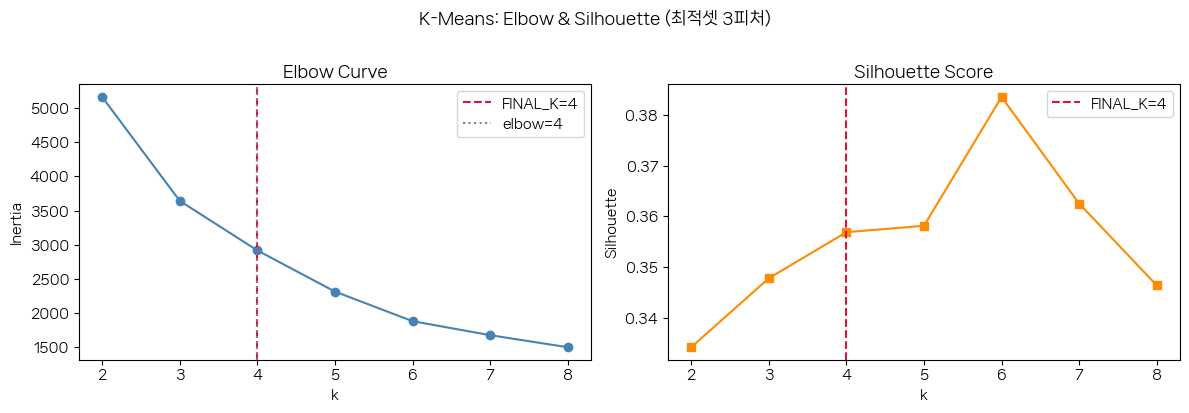

In [3]:
ks = list(range(2, 9))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X)
    inertias.append(km.inertia_); silhouettes.append(silhouette_score(X, km.labels_))

elbow_k = find_elbow_k(ks, inertias)
bestsil_k = ks[int(np.argmax(silhouettes))]
print(f"elbow k={elbow_k}  |  best-sil k={bestsil_k} ({max(silhouettes):.4f})  |  FINAL_K={FINAL_K}")
for k, s in zip(ks, silhouettes):
    tag = "  <-- FINAL_K" if k == FINAL_K else ""
    print(f"  k={k}: {s:.4f}{tag}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertias, "o-", color="steelblue")
ax1.axvline(FINAL_K, linestyle="--", color="crimson", label=f"FINAL_K={FINAL_K}")
ax1.axvline(elbow_k, linestyle=":", color="gray", label=f"elbow={elbow_k}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow Curve")
ax1.set_xticks(ks); ax1.legend()
ax2.plot(ks, silhouettes, "s-", color="darkorange")
ax2.axvline(FINAL_K, linestyle="--", color="crimson", label=f"FINAL_K={FINAL_K}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette Score")
ax2.set_xticks(ks); ax2.legend()
plt.suptitle("K-Means: Elbow & Silhouette (최적셋 3피처)", y=1.02); plt.tight_layout()
plt.savefig("figures/01_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight"); plt.show()


### silhouette 해석 — 주 지표 아님

silhouette **0.36은 "성장량으로 자연스럽게 잘 갈라진 4개 군집"이라 주장하기엔 낮다.** 그러나 이 표본은 성장량이 **연속 스펙트럼**(전원 이벤트 baseline 성장 + 점진적 둔화)이라 군집 경계가 흐릿한 것이 **정상**이다. H1의 목적도 확정 분류가 아니라 **H2/H3용 주차 후보 라벨 생성**이다.

따라서 H1의 주 평가 지표는 silhouette이 아니라:

1. **정체군 profile** — 전투력 감소 + 4-시스템(헥사·유니온·심볼) 저재투자, 고활성 접속.
2. **외부 proxy enrich/recall** — enrich 4.37x, recall 83.0%.
3. **보조 구조 확인** — DBSCAN 교차검증 정합(380↔355). 같은 피처 공간에서 K-Means 정체군집이 밀도 기반 군집과도 상당히 겹치는지 확인한다.
4. **H2/H3 다운스트림 재현성** — 후보 라벨이 분포검정·rule 추출에서 안정적으로 작동하는지.

silhouette은 k 선택의 **보조 신호**로만 본다(운영점 elbow k=4 채택, best-sil k=6 병기).

In [4]:
km_best = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
df_final.loc[idx, "cluster_km"] = km_best.fit_predict(X)
final_sil = silhouette_score(X, km_best.labels_)

# 성장 정체 클러스터 식별 (아래 centroid 규칙)
g = df_final.loc[idx].groupby("cluster_km")
profile = g[CLUSTER_FEATURES].mean()
profile["n"] = g.size()
profile["park%(stag>=4)"]  = g.apply(lambda x: park.loc[x.index].mean() * 100)
profile["stag4%"]          = g.apply(lambda x: stag4.loc[x.index].mean() * 100)
profile["Δlv≤0.1%"]        = g.apply(lambda x: parked_proxy.loc[x.index].mean() * 100)
# 성장 정체 클러스터 = 스케일 중심좌표 합 최저(상대 성장 최하) — feature_selection.ipynb 동일 규칙
stagnant_cluster_id = int(km_best.cluster_centers_.sum(axis=1).argmin())
profile["is_stagnant_cluster"] = (profile.index == stagnant_cluster_id).astype(int)

print(f"FINAL_K={FINAL_K}  silhouette={final_sil:.4f}  성장 정체 클러스터 ID={stagnant_cluster_id}\n")
display(profile.round(3).T)

print("\n레벨 밴드 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx, "cluster_km"], df_final.loc[idx, "level_bin"],
                     normalize="index") * 100).round(1))
if "class_group" in df_final.columns:
    print("\n계열 분포 (행 비율 %):")
    display((pd.crosstab(df_final.loc[idx, "cluster_km"], df_final.loc[idx, "class_group"],
                         normalize="index") * 100).round(1))


FINAL_K=4  silhouette=0.3569  성장 정체 클러스터 ID=1



cluster_km,0.0,1.0,2.0,3.0
slog_delta_cp,15.050,-14.540,15.451,14.153
delta_hexa,2.088,1.327,6.104,1.329
log_delta_union,3.595,2.238,3.880,0.746
log_delta_auth,0.428,0.220,1.143,0.245
n,882.000,380.000,551.000,187.000
park%(stag>=4),0.227,32.105,0.000,12.299
stag4%,0.227,32.105,0.000,12.299
Δlv≤0.1%,9.751,35.789,0.181,33.155
is_stagnant_cluster,0.000,1.000,0.000,0.000



레벨 밴드 분포 (행 비율 %):


level_bin,270-279,280-285,286-290
cluster_km,,,
0.0,6.5,65.3,28.2
1.0,6.6,71.3,22.1
2.0,0.9,35.4,63.7
3.0,10.7,71.7,17.6



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
cluster_km,,,,,
0.0,19.3,20.3,19.8,21.7,18.9
1.0,19.7,18.4,21.8,23.4,16.6
2.0,20.5,21.8,18.3,14.5,24.9
3.0,22.5,16.6,21.9,21.4,17.6


## PCA 2D 시각화 (주차 후보 / stagnation / level_bin)

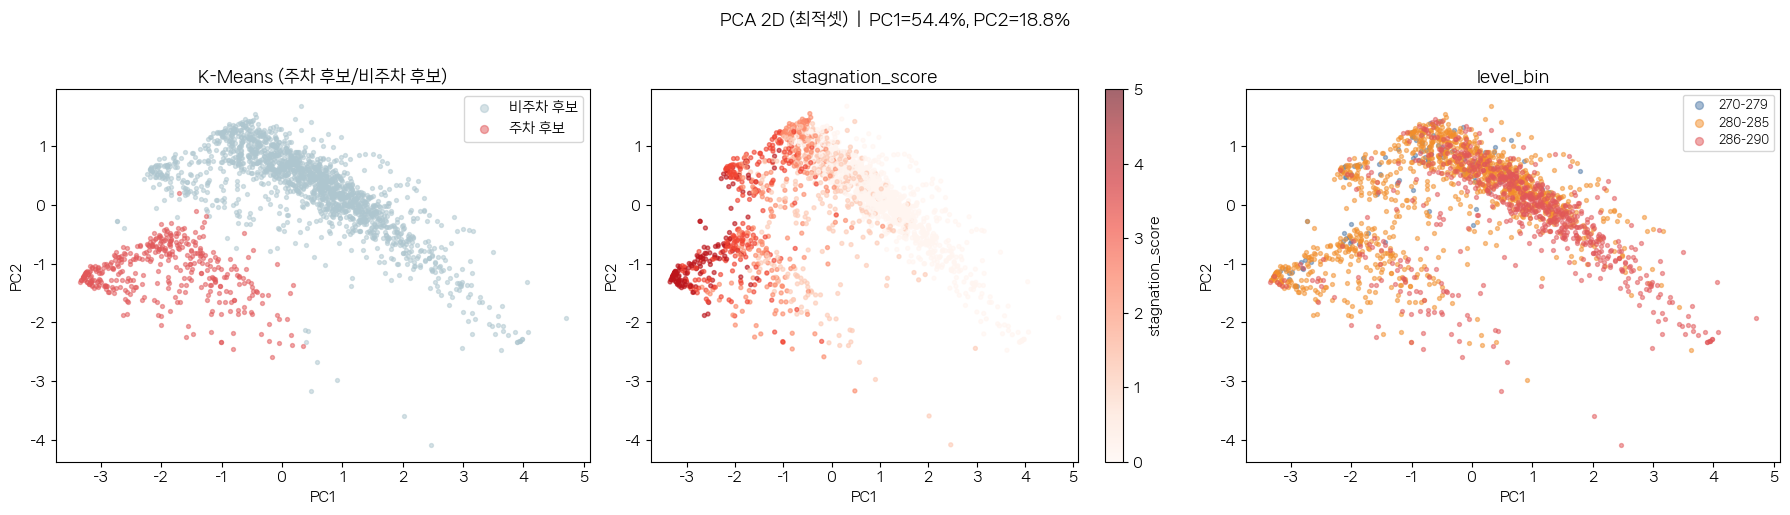

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=idx).join(
    df_final[["cluster_km", "stagnation_score", "level_bin"]])
pca_df["is_stagnant_cluster"] = (pca_df["cluster_km"] == stagnant_cluster_id).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cl, (color, lbl) in enumerate(zip(["#aec6cf", "#e15759"], ["비주차 후보", "주차 후보"])):
    m = pca_df["is_stagnant_cluster"] == cl
    axes[0].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"], s=8, alpha=0.5, color=color, label=lbl)
axes[0].set_title("K-Means (주차 후보/비주차 후보)"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2)

sc = axes[1].scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["stagnation_score"],
                     cmap="Reds", s=8, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label="stagnation_score")
axes[1].set_title("stagnation_score"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

for band in BAND_LABELS:
    m = pca_df["level_bin"].astype(str) == band
    if m.sum() > 0:
        axes[2].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"], s=8, alpha=0.5,
                        color=BAND_PALETTE.get(band, "gray"), label=band)
axes[2].set_title("level_bin"); axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend(markerscale=2, fontsize=8)

ev = pca.explained_variance_ratio_
plt.suptitle(f"PCA 2D (최적셋)  |  PC1={ev[0]:.1%}, PC2={ev[1]:.1%}", y=1.02); plt.tight_layout()
plt.savefig("figures/02_pca_3panel.png", dpi=150, bbox_inches="tight"); plt.show()


## DBSCAN: 밀도 기반 교차검증

k-distance plot으로 eps 자동 결정(min_samples=2·dim=4 = 8) → K-Means 주차 후보 레이블과 교차표로 일관성 확인. **DBSCAN은 k·중심합 규칙 없이 밀도만으로 군집화** → K-Means 정체군집과 정합하면 군집이 partition 아티팩트가 아니라 실제 밀도 구조임을 독립 입증(silhouette보다 강한 구조 근거).

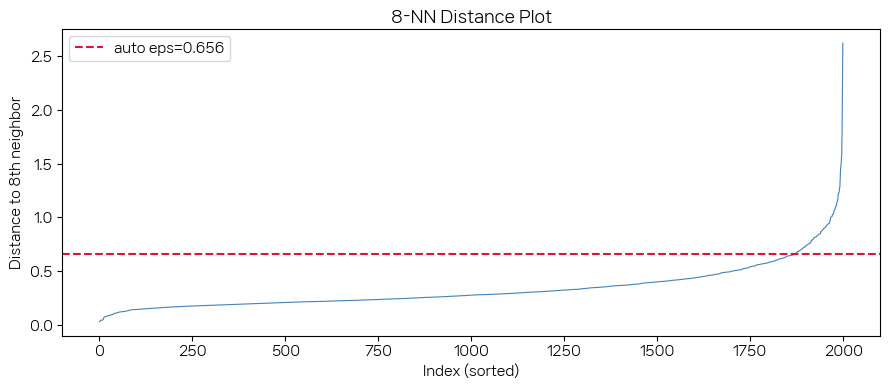

DBSCAN: 3개 클러스터, noise=2.9%, eps=0.6556
    count
-1     59
 0   1578
 1    355
 2      8

K-Means(주차 후보) x DBSCAN 교차표:


DBSCAN,-1,0,1,2
KM parking=1,,,,
0,39,1578,0,3
1,20,0,355,5


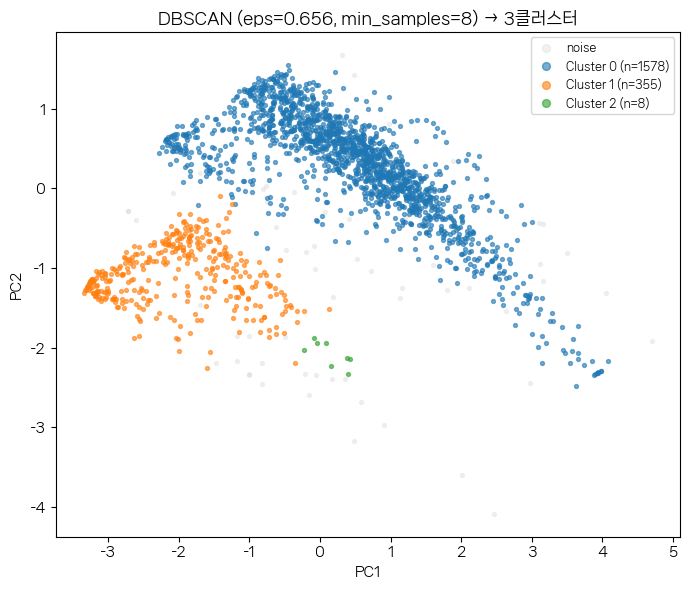

In [6]:
MIN_SAMPLES = 2 * len(CLUSTER_FEATURES)   # = 6
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
dists = np.sort(nbrs.kneighbors(X)[0][:, MIN_SAMPLES - 1])
y_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-12)
x_norm = np.linspace(0, 1, len(y_norm))
eps_auto = float(dists[int(np.argmax(np.abs(y_norm - x_norm)))])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists, color="steelblue", linewidth=0.8)
ax.axhline(eps_auto, linestyle="--", color="crimson", label=f"auto eps={eps_auto:.3f}")
ax.set_title(f"{MIN_SAMPLES}-NN Distance Plot"); ax.set_xlabel("Index (sorted)")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}th neighbor"); ax.legend()
plt.tight_layout()
plt.savefig("figures/03_dbscan_kdist.png", dpi=150, bbox_inches="tight"); plt.show()

db = DBSCAN(eps=eps_auto, min_samples=MIN_SAMPLES).fit(X)
df_final.loc[idx, "cluster_db"] = db.labels_
n_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"DBSCAN: {n_db}개 클러스터, noise={ (db.labels_==-1).mean():.1%}, eps={eps_auto:.4f}")
print(pd.Series(db.labels_).value_counts().sort_index().rename("count").to_frame().to_string())

is_stagnant_km = (df_final.loc[idx, "cluster_km"] == stagnant_cluster_id).astype(int)
print("\nK-Means(주차 후보) x DBSCAN 교차표:")
display(pd.crosstab(is_stagnant_km, db.labels_, rownames=["KM parking=1"], colnames=["DBSCAN"]))

# ── DBSCAN PCA 2D 시각화 ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
labs = df_final.loc[idx, "cluster_db"].values
palette = plt.cm.tab10.colors
for lbl in sorted(set(labs)):
    m = labs == lbl
    color = "lightgray" if lbl == -1 else palette[int(lbl) % 10]
    name = "noise" if lbl == -1 else f"Cluster {int(lbl)} (n={int(m.sum())})"
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.3 if lbl == -1 else 0.6,
               color=color, label=name)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN (eps={eps_auto:.3f}, min_samples={MIN_SAMPLES}) → {n_db}클러스터")
ax.legend(markerscale=2, fontsize=8); plt.tight_layout()
plt.savefig("figures/04_dbscan_clusters.png", dpi=150, bbox_inches="tight"); plt.show()


In [7]:
df_final["is_stagnant_cluster"] = pd.Series(pd.NA, index=df_final.index, dtype="Int64")
df_final.loc[idx, "is_stagnant_cluster"] = (
    df_final.loc[idx, "cluster_km"] == stagnant_cluster_id).astype(int)
df_final.loc[idx, ["ocid", "cluster_km", "is_stagnant_cluster"]].to_csv(
    "../data/cluster_labels.csv", index=False, encoding="utf-8-sig")

n_stagnant = int(df_final["is_stagnant_cluster"].sum())
verdict = "성장 정체 군집 분리 가능" if final_sil > 0.3 else "약한 분리"
# 성장 정체 클러스터의 외부신호 enrich
pk = df_final["is_stagnant_cluster"].fillna(0).eq(1)
enrich = park[pk.values].mean() / max(park.mean(), 1e-9)
recall = park[pk.values].sum() / max(park.sum(), 1)

print("=" * 56)
print("  H1 판정 (최적 피처셋)")
print("=" * 56)
print(f"  피처             : {CLUSTER_FEATURES}")
print(f"  k / Silhouette   : {FINAL_K} / {final_sil:.4f}")
print(f"  판정             : {verdict}")
print(f"  성장 정체 클러스터    : {n_stagnant}명 ({n_stagnant/len(df_final):.1%})")
print(f"  park(stag>=4)    : enrich={enrich:.2f}x, recall={recall:.1%}")
print()
print("  data/cluster_labels.csv 저장 완료")
print("  다음: H2 분포검정 (Chi-Square by level_band & class_group)")


  H1 판정 (최적 피처셋)
  피처             : ['slog_delta_cp', 'delta_hexa', 'log_delta_union', 'log_delta_auth']
  k / Silhouette   : 4 / 0.3569
  판정             : 성장 정체 군집 분리 가능
  성장 정체 클러스터    : 380명 (19.0%)
  park(stag>=4)    : enrich=4.37x, recall=83.0%

  data/cluster_labels.csv 저장 완료
  다음: H2 분포검정 (Chi-Square by level_band & class_group)


---
## 요약

- H1 가설: 최근 6개월간 주요 성장 지표가 낮은 활성 캐릭터들은 일반 성장 캐릭터들과 구분되는 성장 정체 군집으로 식별될 것이다.
- 채택셋 **4피처 `[cp_slog, hexa_avg, union_log, auth_log]`**(`feature_selection.ipynb` / `optimal_feature_set.json`)로 K-Means 실행. 6mo delta = `recent6_delta_*`(features_monthly 단독 재현).
- 최종 K-Means **k=4(elbow)**, silhouette@k4 `0.357`(best-sil k=6: 0.384). silhouette는 보조 지표(위 "silhouette 해석" 참조) — 성장량 연속 스펙트럼이라 경계 흐림이 정상.
- 성장 정체 cluster는 `cluster_km == 1`, `data/cluster_labels.csv` 기준 **380명(19.0%)** of 2,000. 외부 proxy(stag≥4) **enrich 4.37x, recall 83.0%**.
- DBSCAN **3군집·noise 2.9%**(eps 0.656): 정체 380 ↔ DBSCAN cluster1(355) **강한 정합** → 같은 피처 공간에서의 보조 구조 확인.
- 판정: 조작적 정의 기준으로 H1을 지지한다. 상세 결과·프로파일은 `h1_clustering/RESULT.md`.
- H2/H3는 이 `is_stagnant_cluster`(380) **단일 라벨**을 입력으로 사용(현재성 라벨 폐기). H2/H3 재실행 완료.
